In [ ]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Generation & Loading

In [2]:
# Generate synthetic customer data
np.random.seed(42)
n_samples = 1000

data = {
    'CustomerID': range(1, n_samples + 1),
    'Age': np.random.randint(18, 70, n_samples),
    'Tenure': np.random.randint(1, 72, n_samples),  # months
    'MonthlyCharges': np.random.uniform(20, 120, n_samples),
    'TotalCharges': np.random.uniform(100, 8000, n_samples),
    'ContractType': np.random.choice(['Month-to-Month', 'One Year', 'Two Year'], n_samples, p=[0.5, 0.3, 0.2]),
    'PaymentMethod': np.random.choice(['Electronic', 'Mailed Check', 'Bank Transfer', 'Credit Card'], n_samples),
    'NumProducts': np.random.randint(1, 5, n_samples),
    # number of support calls
    'CustomerSupport': np.random.randint(0, 10, n_samples),
}

df = pd.DataFrame(data)

# Create target variable (Churn) based on patterns
churn_probability = (
    0.1 +  # base probability
    (df['ContractType'] == 'Month-to-Month') * 0.3 +
    (df['Tenure'] < 12) * 0.2 +
    (df['CustomerSupport'] > 5) * 0.25 +
    (df['MonthlyCharges'] > 80) * 0.15 +
    np.random.uniform(-0.1, 0.1, n_samples)
)

df['Churn'] = (churn_probability > 0.5).astype(int)

print(f"Dataset created with {len(df)} customers")
print(f"Churn Rate: {df['Churn'].mean()*100:.2f}%")
df.head(10)

Dataset created with 1000 customers
Churn Rate: 41.10%


,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,ContractType,PaymentMethod,NumProducts,CustomerSupport,Churn
0,1,56,15,55.162269,2465.225148,Month-to-Month,Electronic,2,3,0
1,2,69,64,30.142083,2933.852651,Month-to-Month,Credit Card,3,0,0
2,3,46,28,68.587176,6455.053941,Month-to-Month,Mailed Check,2,5,0
3,4,32,39,45.677657,2302.202992,Month-to-Month,Electronic,2,1,0
4,5,60,57,48.487290,1764.569215,Two Year,Bank Transfer,4,4,0
5,6,25,17,50.728996,7663.839350,One Year,Bank Transfer,2,6,0
6,7,38,44,100.302590,170.019952,Two Year,Bank Transfer,4,1,0
7,8,56,25,73.916128,7982.784760,Month-to-Month,Electronic,3,5,0
8,9,36,17,51.130770,5446.888261,Month-to-Month,Credit Card,2,5,0
9,10,40,13,81.033378,6644.907466,One Year,Mailed Check,2,4,0


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Basic information
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (1000, 10)

Data Types:
CustomerID           int64
Age                  int32
Tenure               int32
MonthlyCharges     float64
TotalCharges       float64
ContractType        object
PaymentMethod       object
NumProducts          int32
CustomerSupport      int32
Churn                int32
dtype: object

Missing Values:
CustomerID         0
Age                0
Tenure             0
MonthlyCharges     0
TotalCharges       0
ContractType       0
PaymentMethod      0
NumProducts        0
CustomerSupport    0
Churn              0
dtype: int64

Basic Statistics:


,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,NumProducts,CustomerSupport,Churn
count,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.81900,35.45900,69.976592,4051.336369,2.492000,4.511000,0.411000
std,288.819436,14.99103,20.36819,28.622115,2294.200703,1.120353,2.901775,0.492261
min,1.000000,18.00000,1.00000,20.156511,100.091915,1.000000,0.000000,0.000000
25%,250.750000,31.00000,17.75000,45.739956,2072.787161,2.000000,2.000000,0.000000
50%,500.500000,44.00000,36.00000,70.620396,4095.788642,2.000000,4.000000,0.000000
75%,750.250000,56.00000,53.00000,94.329338,6016.929164,4.000000,7.000000,1.000000
max,1000.000000,69.00000,71.00000,119.834751,7991.251635,4.000000,9.000000,1.000000


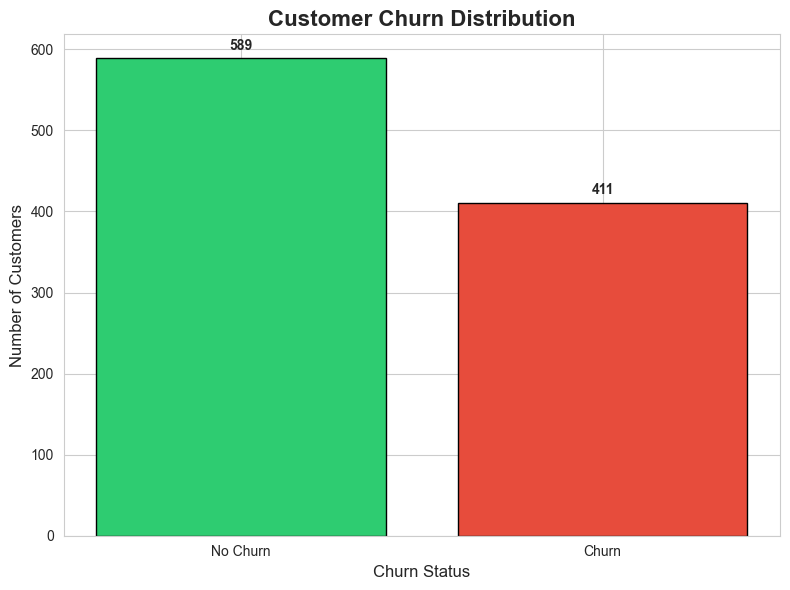

In [4]:
# Churn distribution
plt.figure(figsize=(8, 6))
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.bar(['No Churn', 'Churn'], churn_counts.values,
        color=colors, edgecolor='black')
plt.title('Customer Churn Distribution', fontsize=16, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12)
plt.xlabel('Churn Status', fontsize=12)
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

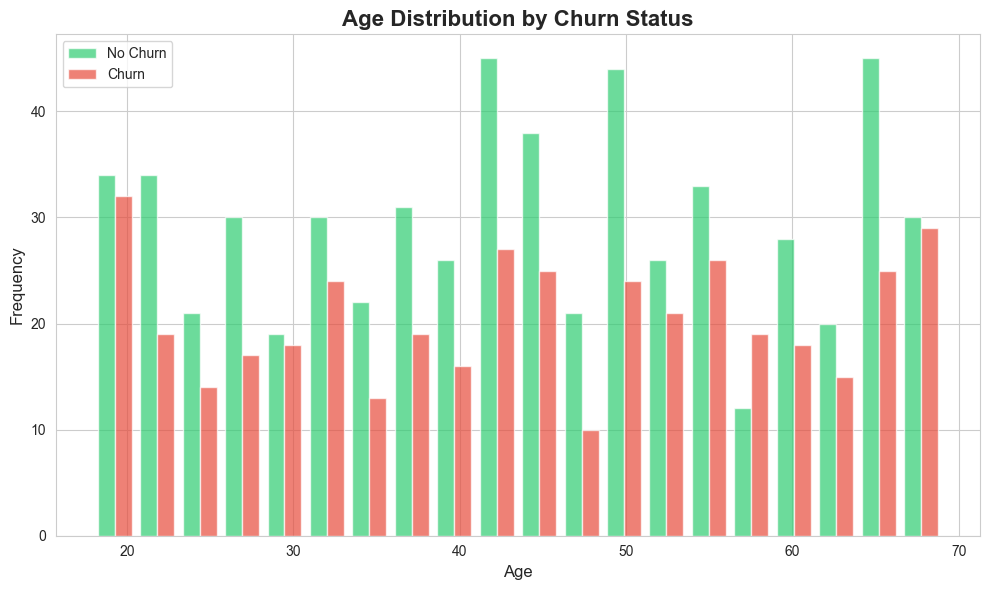

In [5]:
# Age distribution by churn
plt.figure(figsize=(10, 6))
plt.hist([df[df['Churn'] == 0]['Age'], df[df['Churn'] == 1]['Age']],
         bins=20, label=['No Churn', 'Churn'], color=['#2ecc71', '#e74c3c'], alpha=0.7)
plt.title('Age Distribution by Churn Status', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

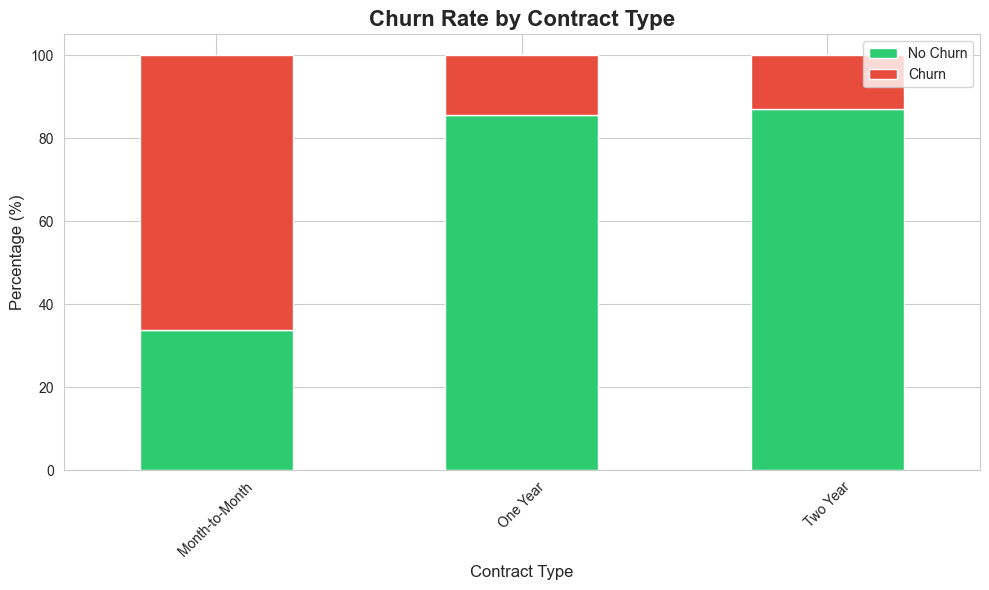

In [6]:
# Churn by Contract Type
plt.figure(figsize=(10, 6))
contract_churn = pd.crosstab(
    df['ContractType'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(['No Churn', 'Churn'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

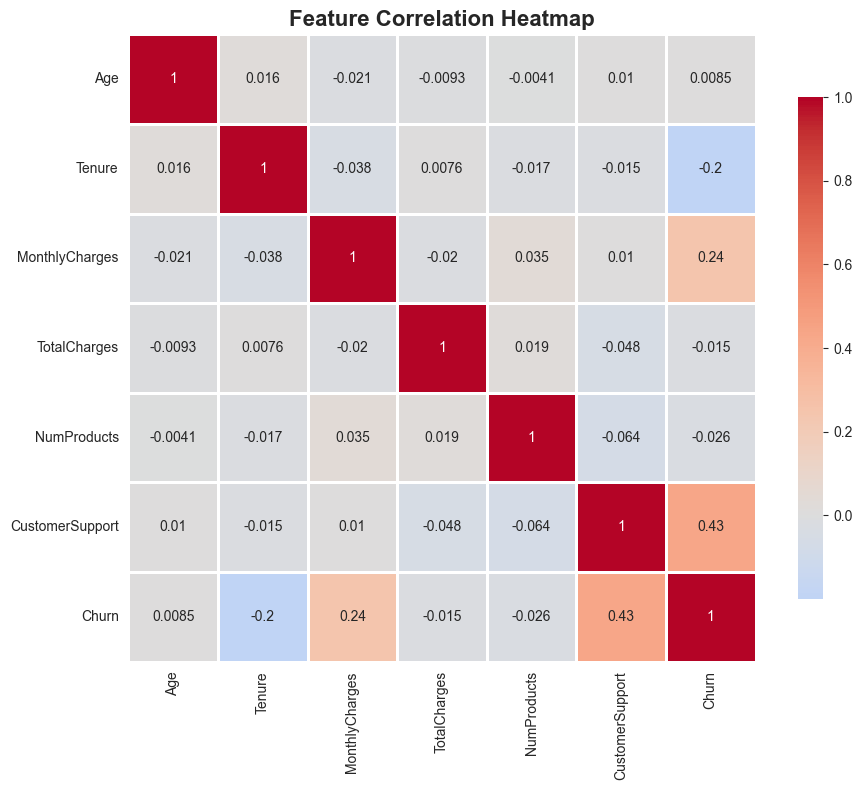

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['Age', 'Tenure', 'MonthlyCharges',
                'TotalCharges', 'NumProducts', 'CustomerSupport', 'Churn']
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

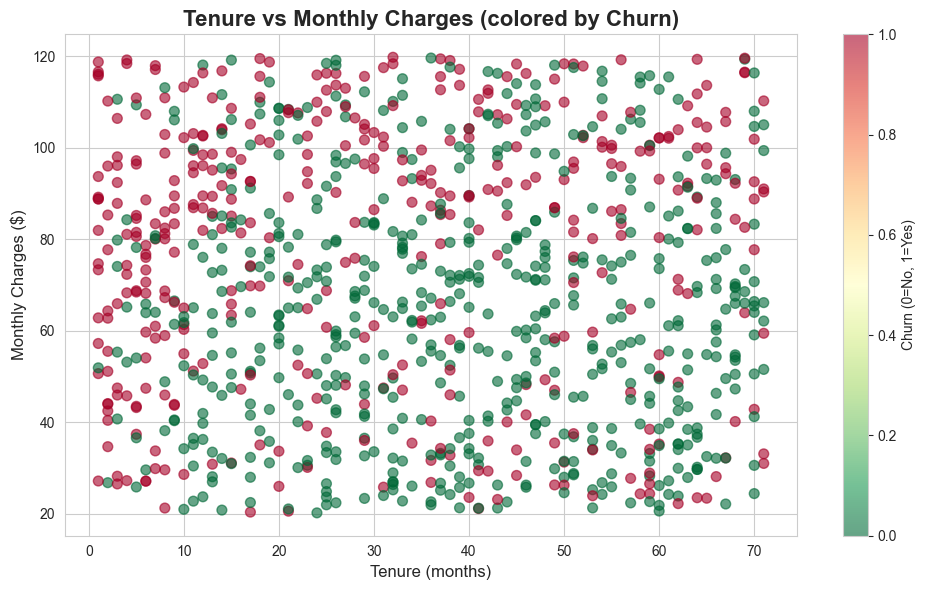

In [8]:
# Tenure vs Monthly Charges scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Tenure'], df['MonthlyCharges'],
                      c=df['Churn'], cmap='RdYlGn_r', alpha=0.6, s=50)
plt.colorbar(scatter, label='Churn (0=No, 1=Yes)')
plt.title('Tenure vs Monthly Charges (colored by Churn)',
          fontsize=16, fontweight='bold')
plt.xlabel('Tenure (months)', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [9]:
# Prepare data for ML
df_ml = df.copy()

# Encode categorical variables
le_contract = LabelEncoder()
le_payment = LabelEncoder()

df_ml['ContractType_Encoded'] = le_contract.fit_transform(
    df_ml['ContractType'])
df_ml['PaymentMethod_Encoded'] = le_payment.fit_transform(
    df_ml['PaymentMethod'])

# Select features
features = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges',
            'NumProducts', 'CustomerSupport', 'ContractType_Encoded', 'PaymentMethod_Encoded']

X = df_ml[features]
y = df_ml['Churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 800
Test set size: 200
Number of features: 8


## 4. Machine Learning Models

### 4.1 Logistic Regression

In [10]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Results:")
print(f"Accuracy: {lr_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Results:
Accuracy: 0.8050

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       118
           1       0.76      0.77      0.76        82

    accuracy                           0.81       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.81      0.81      0.81       200



### 4.2 Decision Tree

In [11]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Results:")
print(f"Accuracy: {dt_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Results:
Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       118
           1       0.84      0.94      0.89        82

    accuracy                           0.90       200
   macro avg       0.90      0.91      0.90       200
weighted avg       0.91      0.90      0.90       200



### 4.3 Random Forest

In [12]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Results:")
print(f"Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results:
Accuracy: 0.9200

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       118
           1       0.87      0.95      0.91        82

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



### 4.4 Support Vector Machine (SVM)

In [13]:
# SVM
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Results:")
print(f"Accuracy: {svm_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

SVM Results:
Accuracy: 0.8550

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       118
           1       0.83      0.82      0.82        82

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



## 5. Model Comparison & Evaluation

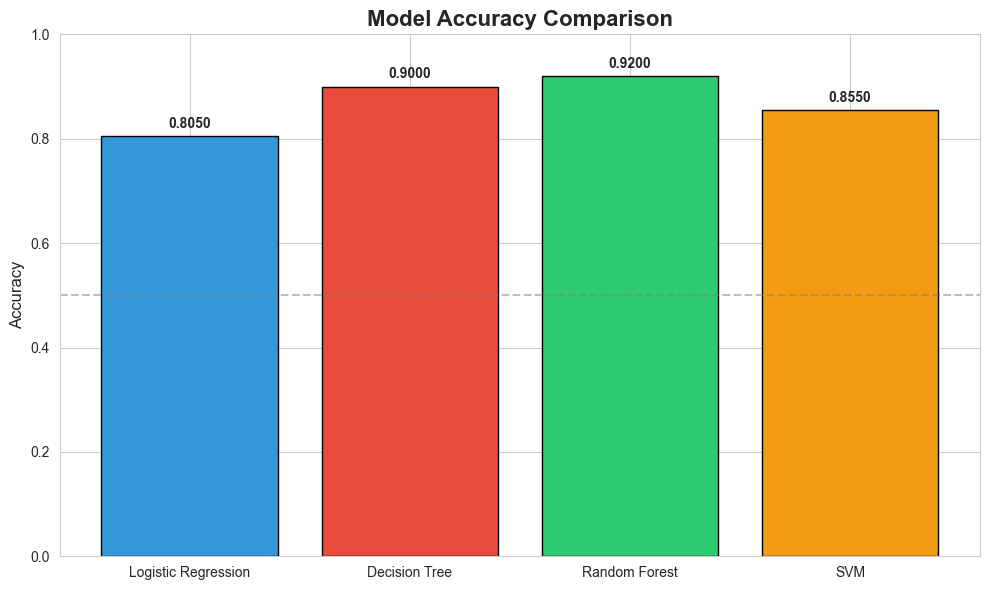


Best Model: Random Forest with accuracy 0.9200


In [14]:
# Compare model accuracies
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']
accuracies = [lr_accuracy, dt_accuracy, rf_accuracy, svm_accuracy]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=[
               '#3498db', '#e74c3c', '#2ecc71', '#f39c12'], edgecolor='black')
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(
    f"\nBest Model: {models[np.argmax(accuracies)]} with accuracy {max(accuracies):.4f}")

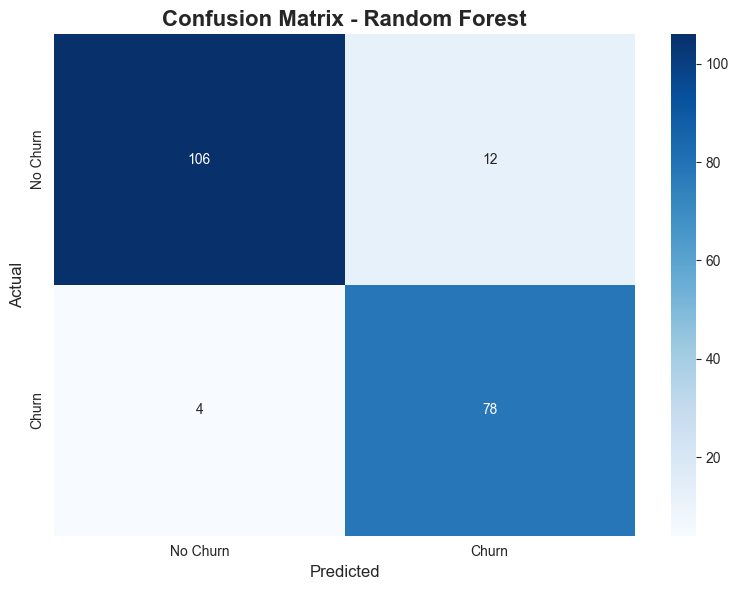

In [15]:
# Confusion Matrix for best model (Random Forest)
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

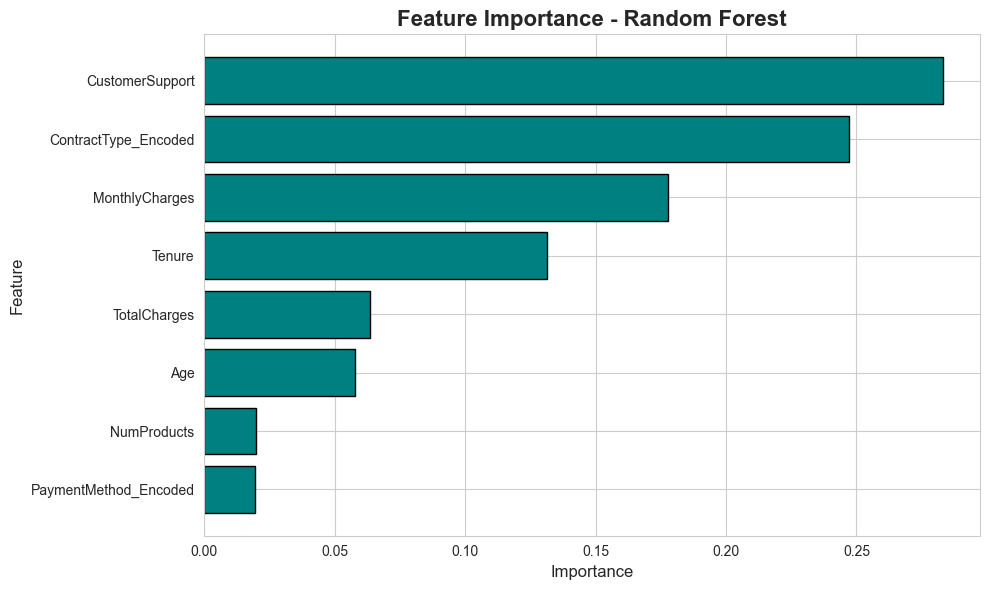


Feature Importance:
                 Feature  Importance
5        CustomerSupport    0.283184
6   ContractType_Encoded    0.247083
2         MonthlyCharges    0.177843
1                 Tenure    0.131532
3           TotalCharges    0.063500
0                    Age    0.057804
4            NumProducts    0.019778
7  PaymentMethod_Encoded    0.019276


In [16]:
# Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'], color='teal', edgecolor='black')
plt.title('Feature Importance - Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(feature_importance)

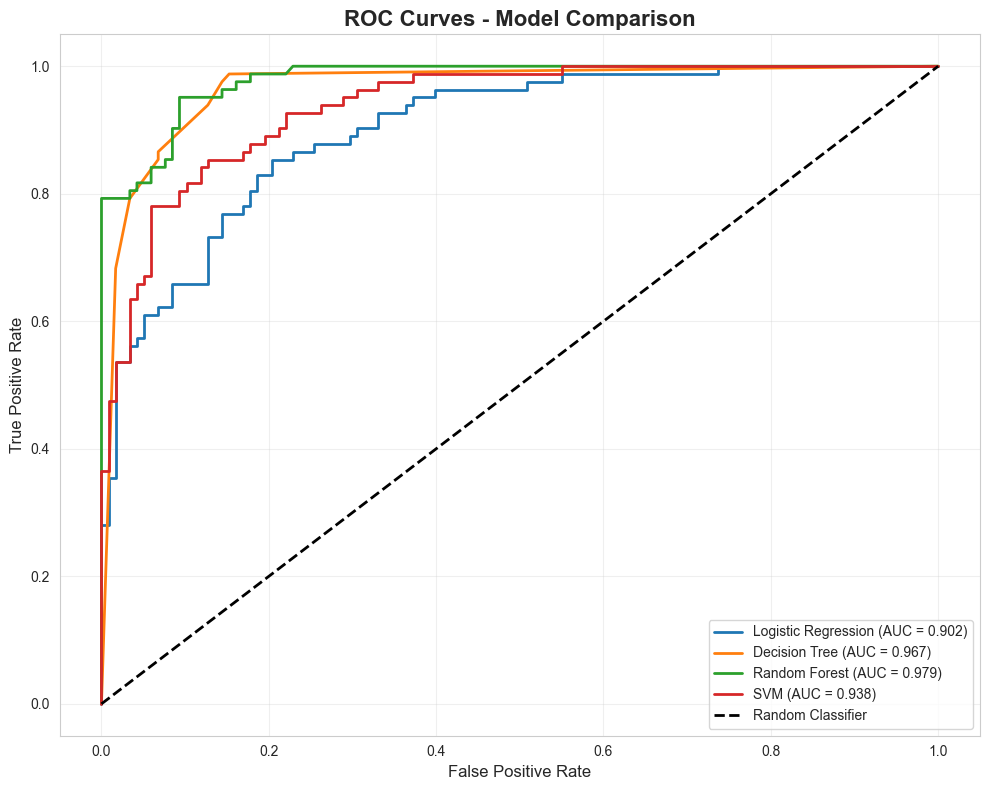

In [17]:
# ROC Curves for all models
plt.figure(figsize=(10, 8))

# Logistic Regression
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)

# Decision Tree
dt_proba = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt,
         label=f'Decision Tree (AUC = {auc_dt:.3f})', linewidth=2)

# Random Forest
rf_proba = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)

# SVM
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_proba)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})', linewidth=2)

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)

plt.title('ROC Curves - Model Comparison', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Key Findings & Insights

In [18]:
print("="*70)
print("KEY FINDINGS & INSIGHTS")
print("="*70)

print("\n1. MODEL PERFORMANCE:")
results_df = pd.DataFrame({
    'Model': models,
    'Accuracy': [f"{acc:.4f}" for acc in accuracies],
    'AUC': [f"{auc_lr:.4f}", f"{auc_dt:.4f}", f"{auc_rf:.4f}", f"{auc_svm:.4f}"]
})
print(results_df.to_string(index=False))

print(f"\n2. BEST MODEL: {models[np.argmax(accuracies)]}")
print(f"   - Accuracy: {max(accuracies):.4f}")
print(f"   - AUC Score: {max([auc_lr, auc_dt, auc_rf, auc_svm]):.4f}")

print("\n3. TOP 3 IMPORTANT FEATURES:")
for idx, row in feature_importance.head(3).iterrows():
    print(f"   - {row['Feature']}: {row['Importance']:.4f}")

print("\n4. BUSINESS INSIGHTS:")
print(f"   - Overall churn rate: {df['Churn'].mean()*100:.2f}%")
print(f"   - Month-to-Month contracts have highest churn risk")
print(f"   - Customer support calls and tenure are key predictors")
print(f"   - Early intervention (first 12 months) is crucial")

print("\n" + "="*70)

KEY FINDINGS & INSIGHTS

1. MODEL PERFORMANCE:
              Model Accuracy    AUC
Logistic Regression   0.8050 0.9016
      Decision Tree   0.9000 0.9666
      Random Forest   0.9200 0.9794
                SVM   0.8550 0.9383

2. BEST MODEL: Random Forest
   - Accuracy: 0.9200
   - AUC Score: 0.9794

3. TOP 3 IMPORTANT FEATURES:
   - CustomerSupport: 0.2832
   - ContractType_Encoded: 0.2471
   - MonthlyCharges: 0.1778

4. BUSINESS INSIGHTS:
   - Overall churn rate: 41.10%
   - Month-to-Month contracts have highest churn risk
   - Customer support calls and tenure are key predictors
   - Early intervention (first 12 months) is crucial

